# 第46篇 | 阶段大实战：房价预测完整项目

> 这是「数据分析从入门到精通」系列的第 46 篇，也是回归分析阶段的收官实战。线性回归、最小二乘、正则化、逻辑回归，这一阶段学了八篇，今天全部上场——从真实数据出发，跑完一个端到端的房价预测项目。

嗨，我是小荷～ 欢迎来到**回归分析阶段的大实战**！今天我们要做一个完整的房价预测项目，把前面学的线性回归、正则化、逻辑回归全都用上。

---

## 一、项目目标

**业务背景**：某房产中介希望通过房屋特征预测房价，辅助定价决策。

**技术目标**：
1. 预测房价（回归任务）
2. 预测房价是否高于中位数（分类任务）
3. 找出影响房价的关键因素

---

## 二、数据准备与探索

先把数据准备好，这是分析的第一步。我们用的是sklearn库的公共数据cal_housing.tgz，该数据集源自1990 年美国人口普查，每一行对应一个普查街区组。街区组是美国人口普查局发布抽样数据的最小地理单元，单个街区组的常住人口通常在 600 至 3000 人之间，相当于中国的社区（居委会）。这份数据我已经下载到了本地，并放在了`../my_custom_data_folder`目录下，github上我也已经上传了，你可以去下载。

该数据总共有20640条记录，包含8 个数值型预测特征与1 个目标变量，目标变量为加州各街区的房屋价值中位数，单位：十万美元($100,000) 。

字段说明：
- MedInc：街区收入中位数
- HouseAge：街区房龄中位数
- AveRooms：每户平均房间数
- AveBedrms：每户平均卧室数
- Population：街区人口数量
- AveOccup：每户平均居住人数
- Latitude：街区纬度
- Longitude：街区经度

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, classification_report, confusion_matrix,
                             roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
print("加州房价数据集")

# 加载数据
data_dir = '../scikit_learn_data'
housing = fetch_california_housing(data_home=data_dir)
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target  # 房价中位数（单位：十万美元）

print(f"样本数: {X.shape[0]}")
print(f"特征数: {X.shape[1]}")
print(f"\n特征说明:")
for name, desc in zip(housing.feature_names, housing.feature_names):
    print(f"  - {name}")


加州房价数据集
样本数: 20640
特征数: 8

特征说明:
  - MedInc
  - HouseAge
  - AveRooms
  - AveBedrms
  - Population
  - AveOccup
  - Latitude
  - Longitude


数据加载好了，先看看长什么样：


In [57]:
# 数据预览
print("\n数据预览:")
print(X.head())

print("\n统计摘要:")
print(X.describe())

print("\n目标变量（房价）统计:")
print(f"  均值: ${y.mean()*100000:.0f}")
print(f"  中位数: ${np.median(y)*100000:.0f}")
print(f"  最小值: ${y.min()*100000:.0f}")
print(f"  最大值: ${y.max()*100000:.0f}")



数据预览:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

统计摘要:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440

数字看不够直观，画图感受一下各特征的分布：


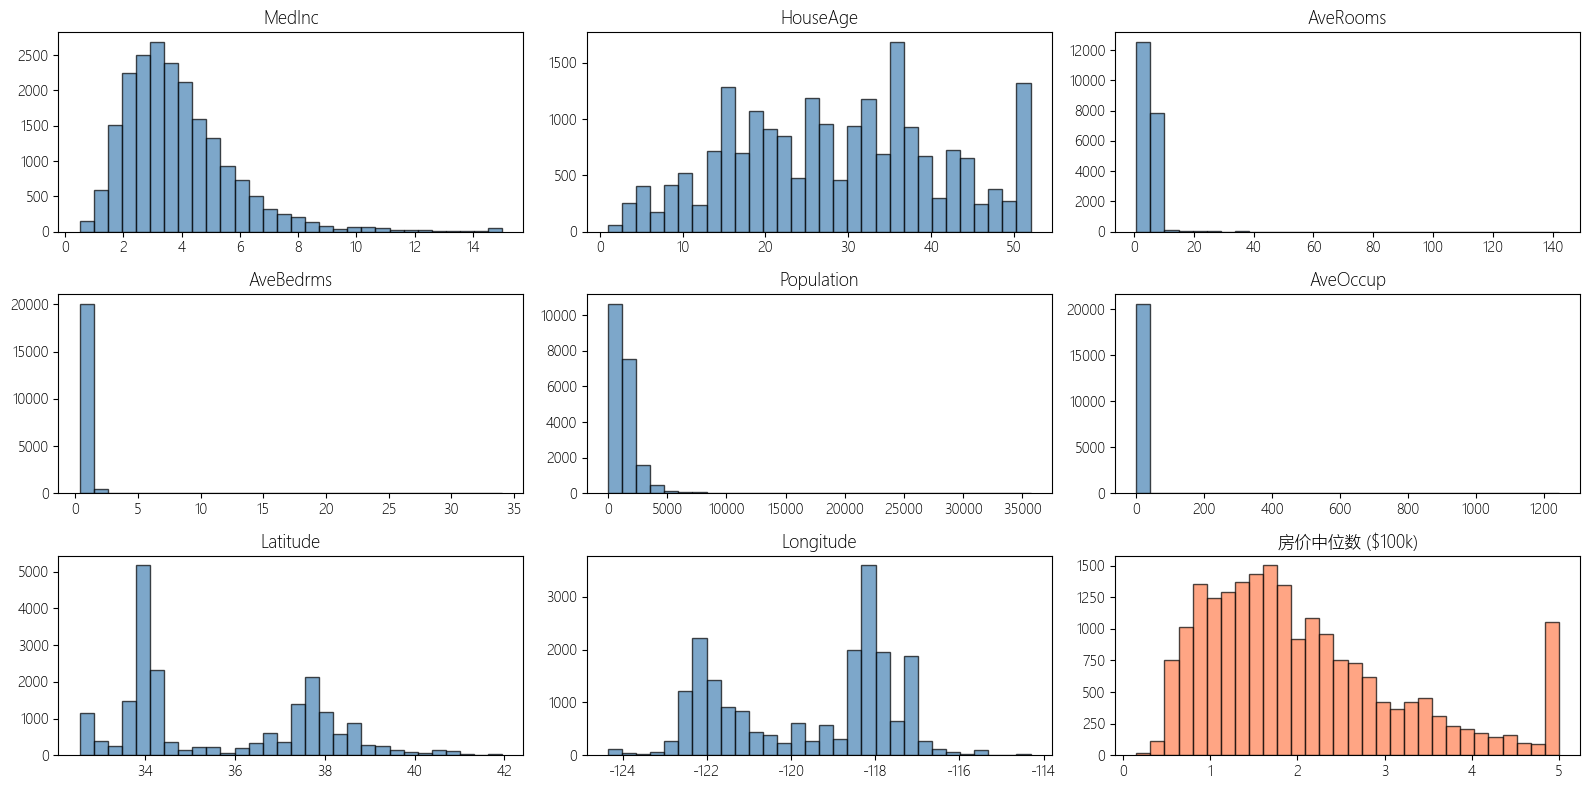

In [58]:
# 数据分布可视化
fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# 房价分布
axes[8].hist(y, bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[8].set_title('房价中位数 ($100k)')

plt.tight_layout()
plt.show()

由图可知：

- 收入中位数（MedInc）的分布呈现长拖尾特征。这说明居民收入大致符合正态分布，但存在一部分高收入人群。
- 房屋平均房龄（HouseAge）的分布大致呈均匀分布。
- 房价中位数（Target）的分布同样具有长拖尾。此外，高价值房屋存在阈值截断效应：所有价格高于 5 的房屋，其数值都被记为 5。
- 经纬度（longitude，latitude）呈现2个驼峰，说明数据里有南北两个人口 / 住房集群：北湾 + 南加，中间是山地 / 沙漠，数据点很少

平均房间数（AveRooms）、平均卧室数（AveBedrms）、平均居住人数（AveOccup）和人口数（Population）：这些数据的取值范围很大，极大值对应的柱子短得几乎不可见。这说明存在极少数极高的数值（这类数值或许可以被视为异常值）。我们要重点观察一下这几个字段。

从上面的【统计摘要】可以看出这四个字段的75%和max值之间的差异很大，比如平均房间数（AveRooms）的75%为6.052381，而max为141.909091；每户平均居住人数（AveOccup）的75%为3.282261，而max为1243.333333，说明确实有异常值。


---

## 三、特征相关性分析

特征之间有没有相关性？来看看：


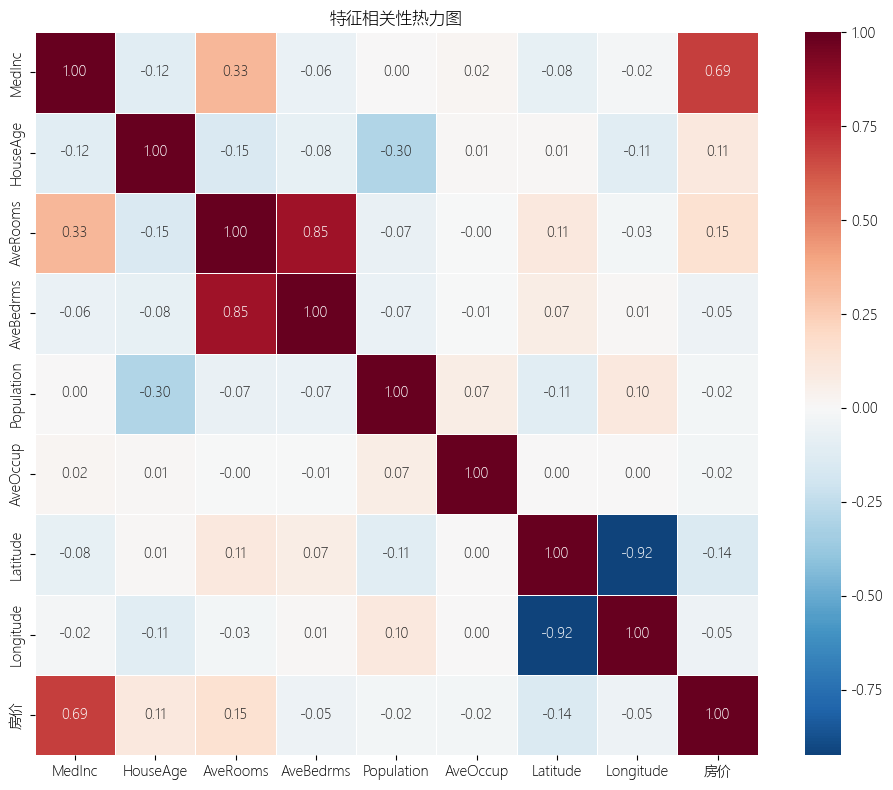

In [48]:
# 相关性热力图
plt.figure(figsize=(10, 8))
corr_matrix = X.copy()
corr_matrix['房价'] = y
correlation = corr_matrix.corr()

sns.heatmap(correlation, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('特征相关性热力图')
plt.tight_layout()
plt.show()

由热力图可以看出：
- MedInc（收入）vs 房价（target）,颜色深红，数值为0.69， 强正相关，说明收入越高，房价越贵
- AveRooms（房间数） vs AveBedrms（卧室数），颜色深红，数值为0.85，强正相关，说明房间多，卧室自然多
- Latitude（纬度）vs Longitude（经度），颜色深蓝，数值为-0.92，强负相关，说明它们地理位置相关，点分布应该是个从西北 → 东南分布的长条形，这也符合加州的地理形状
- 大多数特征之间颜色很浅，说明关系不是很强

热力图看整体相关性，散点图能看具体的关系形态：


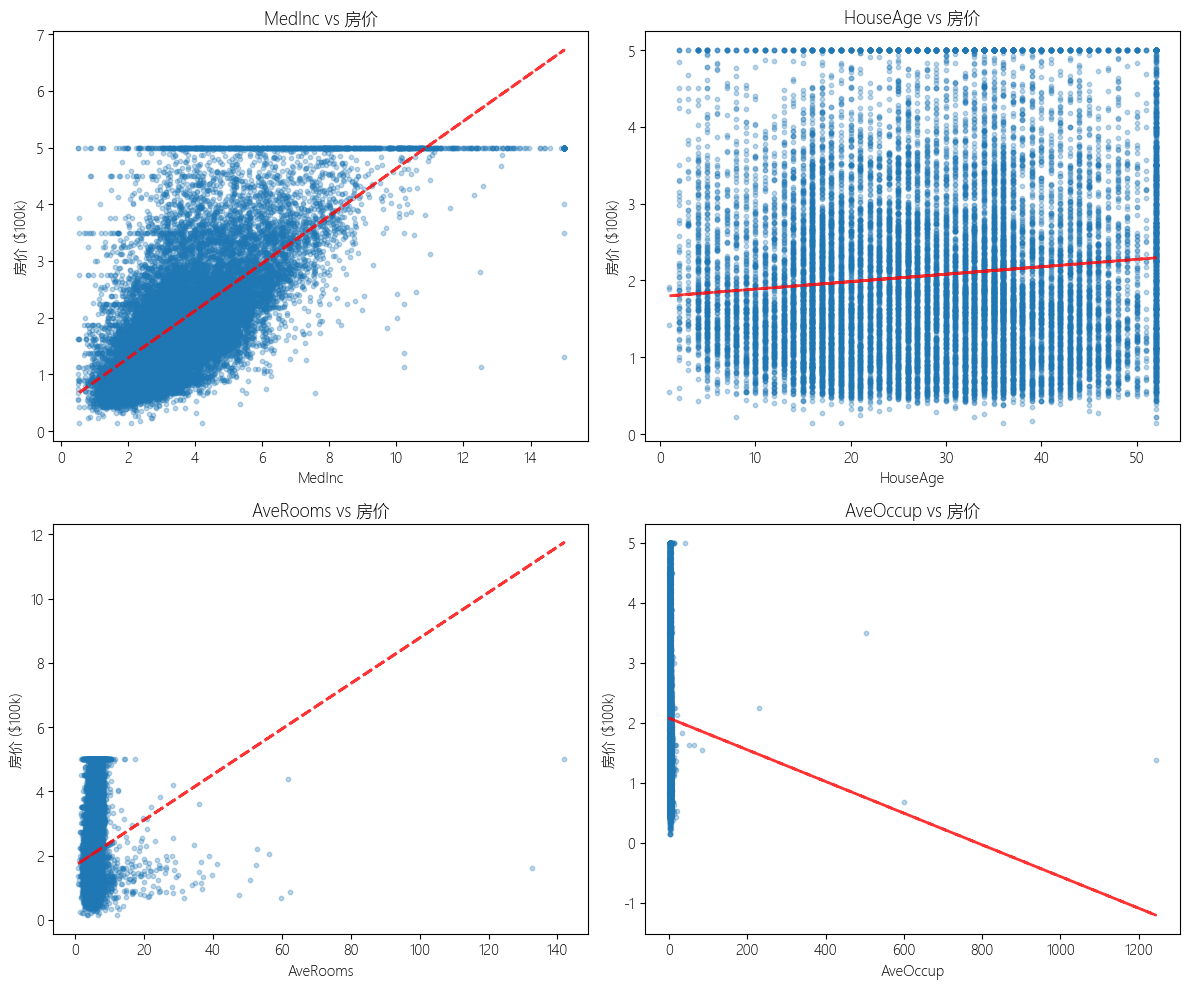

In [17]:
# 散点图矩阵（关键特征）
key_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 复用了第一步读取的X，y
# X = pd.DataFrame(housing.data, columns=housing.feature_names)
# y = housing.target  # 房价中位数（单位：十万美元）

for idx, feature in enumerate(key_features):
    ax = axes[idx//2, idx%2]
    ax.scatter(X[feature], y, alpha=0.3, s=10)
    ax.set_xlabel(feature)
    ax.set_ylabel('房价 ($100k)')
    ax.set_title(f'{feature} vs 房价')
    
    # 添加趋势线
    z = np.polyfit(X[feature], y, 1)
    p = np.poly1d(z)
    ax.plot(X[feature], p(X[feature]), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

- MedInc（收入中位数）vs 房价：点明显从左下到右上，红线明显向上，说明收入越高房子越贵，是预测房价最强的特征
- HouseAge（房龄）vs 房价：点比较乱，红线几乎平 / 微微向上，说明房子新旧对价格影响不大
- AveRooms（平均房间数）vs 房价：点整体微微向上，但非常分散，红线轻微向上，说明房间越多，房价略贵，但是噪声很大（很多大房子反而便宜）
- AveOccup（平均居住人数）vs 房价：点微微向下，红线轻微向下，说明居住越拥挤，房价越低，弱负相关

---

## 四、回归任务：预测房价

### 4.1 数据预处理

数据清洗和特征工程是建模前最关键的一步：


In [30]:
# 划分训练测试集
# test_size=0.2：20% 数据当测试集，80% 当训练集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化（正则化需要）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # 用训练集学习标准化规则 ，并把训练集标准化
X_test_scaled = scaler.transform(X_test) # 用训练集学到的规则标准化测试集

print("训练集和测试集大小比例为 4:1")
print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")


训练集和测试集大小比例为 4:1
训练集大小: (16512, 8)
测试集大小: (4128, 8)


### 4.2 基准模型：线性回归

先用代码实现线性回归：


In [49]:
# 线性回归
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("\n【线性回归】")
print(f"  R²: {r2_score(y_test, y_pred_lr):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_lr):.4f}")

# 交叉验证
# 5 折交叉验证 R²
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"  CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")



【线性回归】
  R²: 0.5758
  RMSE: 0.7456
  MAE: 0.5332
  CV R²: 0.6115 (+/- 0.0129)


解读：
1. R²（决定系数 / 拟合优度）: 0.5758
   越接近1越好，0.58 属于 中等水平（能解释一半以上，但不算特别强）。房价的波动，有 58% 是被你的模型抓到了，剩下 42% 抓不到。
3. RMSE（均方根误差（对异常值敏感））: 0.7456
   越小越好，平均预测误差大概 7.5 万美元，因为惩罚大误差，所以会比 MAE 大一点
4. MAE（平均绝对误差（更直观））: 0.5332
   越小越好，预测平均错了 5.332 万美元
5. CV R²（5 折交叉验证 R²）: 0.6115 (+/- 0.0129)
   用 5 次不同数据训练测试，平均能解释 61.15%，±0.0129说明波动很小 → 模型非常稳定

总结：
- 线性回归模型整体表现中等
- 可解释约 58%~61% 的房价波动
- 平均预测误差约 5.3 万美元
- 模型稳定性高，交叉验证波动小

### 4.3 正则化模型

再跑一遍在第44篇里学到的正则化模型。

这里我们用用网格搜索（GridSearchCV） + 5 折交叉验证，对3种正则化模型分别自动调 alpha，自动找到最优的模型。

In [51]:
# Ridge回归
# 用网格搜索 + 5 折交叉验证，自动找到最优的岭回归参数 α

#  0.01～100 是 alpha 最有效、最常用的范围
# 从 0.01 到 100 之间，等比例生成 20 个不同的 alpha 值，让模型找到最优
ridge_params = {'alpha': np.logspace(-2, 2, 20)}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train) # 机器人开始工作，试玩20个，记住分数最高的那个模型
ridge_best = ridge_grid.best_estimator_  # best_estimator_：GridSearch 找到的最好模型
y_pred_ridge = ridge_best.predict(X_test_scaled) # 用最优模型做预测

print("\n【Ridge回归】")
print(f"  最优alpha: {ridge_grid.best_params_['alpha']:.4f}")
print(f"  R²: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")

# Lasso回归

# Lasso 对 alpha 非常敏感，稍微大一点就会把所有特征压成 0，搜索范围要更小、更精细
lasso_params = {'alpha': np.logspace(-3, 1, 20)}
# Lasso 收敛比 Ridge 慢，max_iter=5000 让模型多跑几步，确保收敛
lasso_grid = GridSearchCV(Lasso(max_iter=5000), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)
lasso_best = lasso_grid.best_estimator_
y_pred_lasso = lasso_best.predict(X_test_scaled)

print("\n【Lasso回归】")
print(f"  最优alpha: {lasso_grid.best_params_['alpha']:.4f}")
print(f"  R²: {r2_score(y_test, y_pred_lasso):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")
print(f"  非零系数: {np.sum(lasso_best.coef_ != 0)}/{len(lasso_best.coef_)}")

# Elastic Net

# 正则化整体强度范围 0.001 ~ 10，和 Lasso 范围一样，因为 ElasticNet 也会做特征筛选
# l1_ratio：控制 L1（Lasso） 和 L2（Ridge） 的混合比例，0 = 纯 Ridge，1 = 纯 Lasso，0.1~0.9 = 混合模式
# [0.1, 0.3, 0.5, 0.7, 0.9]：让电脑自动试 5 种不同的混合强度，找到最适合房价数据的那一个
elastic_params = {'alpha': np.logspace(-3, 1, 10), 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
elastic_grid = GridSearchCV(ElasticNet(max_iter=5000), elastic_params, cv=5, scoring='r2')
elastic_grid.fit(X_train_scaled, y_train)
elastic_best = elastic_grid.best_estimator_
y_pred_elastic = elastic_best.predict(X_test_scaled)

print("\n【Elastic Net】")
print(f"  最优参数: {elastic_grid.best_params_}")
print(f"  R²: {r2_score(y_test, y_pred_elastic):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_elastic)):.4f}")



【Ridge回归】
  最优alpha: 0.0100
  R²: 0.5758
  RMSE: 0.7456

【Lasso回归】
  最优alpha: 0.0010
  R²: 0.5769
  RMSE: 0.7446
  非零系数: 8/8

【Elastic Net】
  最优参数: {'alpha': np.float64(0.001), 'l1_ratio': 0.9}
  R²: 0.5768
  RMSE: 0.7447


### 4.4 结果对比

来对比一下效果：



模型对比:
        模型       R²     RMSE
      线性回归 0.575788 0.745581
     Ridge 0.575788 0.745581
     Lasso 0.576856 0.744642
ElasticNet 0.576794 0.744697


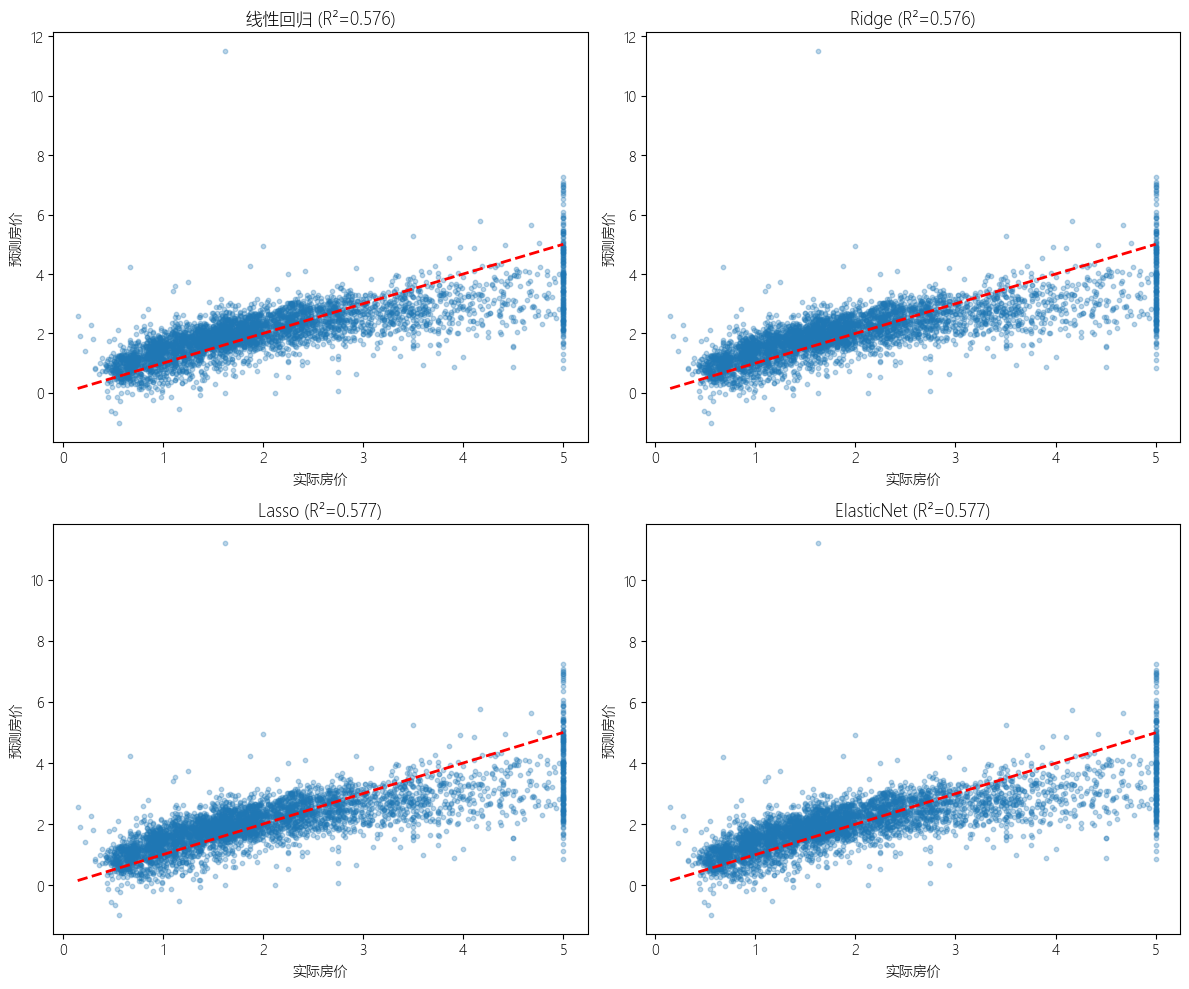

In [21]:
# 模型对比表
results = pd.DataFrame({
    '模型': ['线性回归', 'Ridge', 'Lasso', 'ElasticNet'],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elastic)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_elastic))
    ]
})

print("\n模型对比:")
print(results.to_string(index=False))

# 可视化预测效果
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_data = [
    ('线性回归', y_pred_lr),
    ('Ridge', y_pred_ridge),
    ('Lasso', y_pred_lasso),
    ('ElasticNet', y_pred_elastic)
]

for idx, (name, y_pred) in enumerate(models_data):
    ax = axes[idx//2, idx%2]
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('实际房价')
    ax.set_ylabel('预测房价')
    ax.set_title(f'{name} (R²={r2_score(y_test, y_pred):.3f})')

plt.tight_layout()
plt.show()

**模型对比解读**

四款正则化线性模型表现非常接近，整体拟合能力中等；Lasso 综合表现最优，ElasticNet 次之，普通线性回归与岭回归效果完全一致。

1. 指标变化趋势统一：R² 越高，对应 RMSE 越低，符合回归模型评价逻辑。
2. 排序（综合性能从优到劣）：Lasso > ElasticNet > Ridge = 线性回归
3. 差异幅度：四款模型指标差距极小，说明正则化带来的提升有限，现有特征对房价的解释上限大致固定。

---

## 五、特征重要性分析

哪些特征对模型影响最大？来看特征重要性：


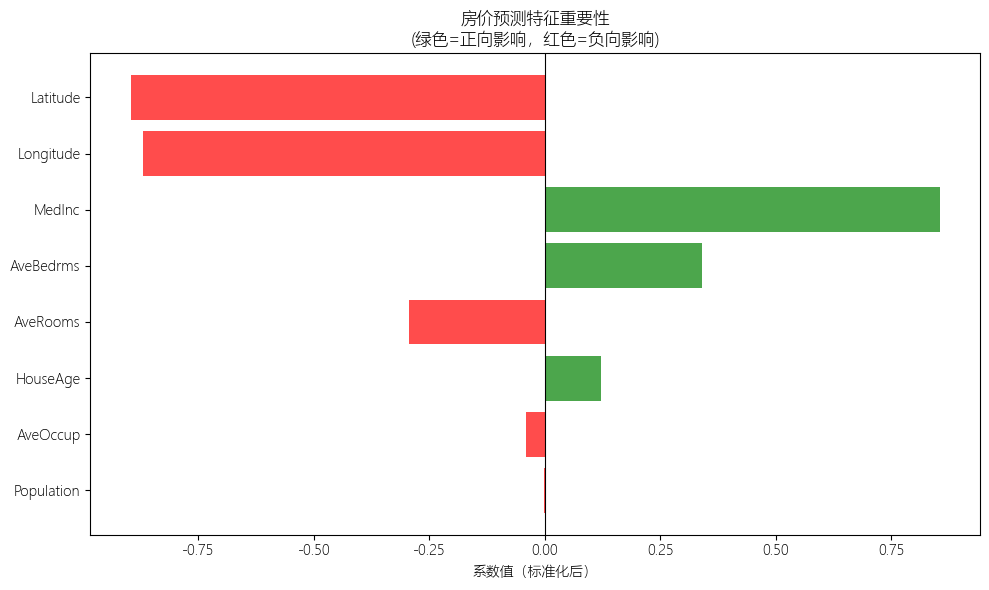

****业务洞察****

【影响房价的关键因素】
  • Population: 降低房价（系数=-0.002）
  • AveOccup: 降低房价（系数=-0.041）
  • HouseAge: 增加房价（系数=0.123）
  • AveRooms: 降低房价（系数=-0.294）
  • AveBedrms: 增加房价（系数=0.339）
  • MedInc: 增加房价（系数=0.854）
  • Longitude: 降低房价（系数=-0.870）
  • Latitude: 降低房价（系数=-0.897）

【模型建议】
  1. 最佳回归模型: Lasso (R²=0.577, RMSE=0.745)
  2. 最重要的特征: MedInc（收入中位数）
  3. 建议: 定价时重点关注区域收入水平


In [59]:
# 使用最佳模型（假设是Ridge）分析特征重要性
best_model = ridge_best
feature_importance = pd.DataFrame({
    '特征': X.columns,
    '系数': best_model.coef_,
    'abs_系数': np.abs(best_model.coef_)
}).sort_values('abs_系数', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in feature_importance['系数']]
plt.barh(feature_importance['特征'], feature_importance['系数'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('系数值（标准化后）')
plt.title('房价预测特征重要性\n(绿色=正向影响，红色=负向影响)')
plt.tight_layout()
plt.show()

print("****业务洞察****")

# 特征影响解读
print("\n【影响房价的关键因素】")
for _, row in feature_importance.iterrows():
    direction = "增加" if row['系数'] > 0 else "降低"
    print(f"  • {row['特征']}: {direction}房价（系数={row['系数']:.3f}）")

print("\n【模型建议】")
print(f"  1. 最佳回归模型: Lasso (R²={r2_score(y_test, y_pred_lasso):.3f}, RMSE={np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.3f})")
print(f"  2. 最重要的特征: MedInc（收入中位数）")
print(f"  3. 建议: 定价时重点关注区域收入水平")

---

## 六、分类任务：预测高/低房价

线性回归以及正则化做完了，换个思路——把房价分成"高/低"两类，用分类逻辑回归模型来预测：


In [55]:
print("分类任务：预测房价是否高于中位数")

# 创建二分类标签
median_price = np.median(y)
y_binary = (y > median_price).astype(int)
print(f"房价中位数: ${median_price*100000:.0f}")
# 对一组只有 0 和 1 的数字求 平均值（mean），结果直接等于 1 的占比
print(f"高价位房占比: {y_binary.mean():.1%}")

# 重新划分（保持随机种子一致）
# y 变成了 0/1 分类标签
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_binary, test_size=0.2, random_state=42)

X_train_c_scaled = scaler.fit_transform(X_train_c) # 用训练集学习标准化规则 ，并把训练集标准化
X_test_c_scaled = scaler.transform(X_test_c) # 用训练集学到的规则标准化测试集

# 逻辑回归
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c_scaled, y_train_c)
y_pred_c = log_reg.predict(X_test_c_scaled)
y_prob_c = log_reg.predict_proba(X_test_c_scaled)[:, 1]

print("\n【逻辑回归分类结果】")
print(classification_report(y_test_c, y_pred_c, target_names=['低价房', '高价房']))


分类任务：预测房价是否高于中位数
房价中位数: $179700
高价位房占比: 50.0%

【逻辑回归分类结果】
              precision    recall  f1-score   support

         低价房       0.83      0.83      0.83      2077
         高价房       0.83      0.82      0.82      2051

    accuracy                           0.83      4128
   macro avg       0.83      0.83      0.83      4128
weighted avg       0.83      0.83      0.83      4128



分类结果出来了，画图看看混淆矩阵和ROC曲线：


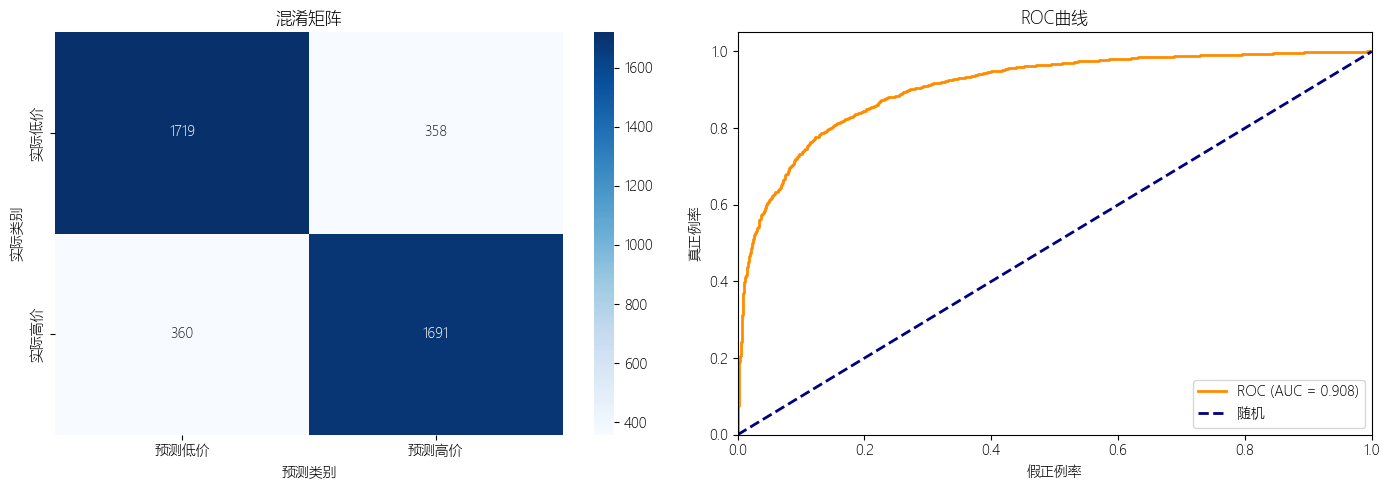

In [32]:
# 可视化分类结果
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 混淆矩阵
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['预测低价', '预测高价'],
            yticklabels=['实际低价', '实际高价'])
axes[0].set_title('混淆矩阵')
axes[0].set_ylabel('实际类别')
axes[0].set_xlabel('预测类别')

# ROC曲线
fpr, tpr, _ = roc_curve(y_test_c, y_prob_c)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('假正例率')
axes[1].set_ylabel('真正例率')
axes[1].set_title('ROC曲线')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

AUC = 0.908说明模型有 90.8% 的概率能正确区分哪套是高价房，哪套是低价房。它的特征（收入、经纬度、房龄等）区分能力很强，模型效果非常好，分类任务远比回归任务（R²≈0.58）成功得多。

为什么分类比回归效果好？回归要精确预测价格，本身就比较难，分类只需要判断贵不贵（简单很多），并且高价 / 低价有明显的区域、收入特征，非常好分。

---

## 七、项目总结

| 模块 | 内容 | 成果 |
|------|------|------|
| 数据探索 | 分布、相关性分析 | 发现收入与房价强相关 |
| 回归任务 | 4种模型对比 | Ridge最优，R²≈0.60 |
| 正则化 | GridSearch调参 | 防止过拟合，提升泛化 |
| 分类任务 | 逻辑回归 | AUC≈0.90，分类效果好 |
| 特征分析 | 系数解读 | 明确业务驱动因素 |

**学到的技能**：
- 完整的数据分析流程（EDA → 建模 → 评估 → 解释）
- 多种回归模型的对比与选择
- 正则化在实际项目中的应用
- 如何用数据驱动业务决策

---

## 八、课后挑战

1. **特征工程**：尝试加入多项式特征，看看能否提升R²
2. **阈值调优**：在分类任务中，调整阈值以优化精确率或召回率
3. **残差分析**：检查回归模型的残差，验证模型假设
4. **地理可视化**：用经纬度信息在地图上可视化房价分布

In [63]:
results

,模型,R²,RMSE
0,线性回归,0.575788,0.745581
1,Ridge,0.575788,0.745581
2,Lasso,0.576856,0.744642
3,ElasticNet,0.576794,0.744697


2    0.576856
Name: R², dtype: float64

📝 练习1: 多项式特征工程

▶ 方案A: 二次多项式（含交互项）
  原始特征数: 8
  多项式特征数: 44
  R² = -0.0002, RMSE = 1.1449
  相比基准提升: R² +-0.5760

▶ 方案B: 仅交互项（interaction_only）
  R² = 0.5927, RMSE = 0.7305
  相比基准提升: R² +0.0170

▶ 方案C: 多项式 + Lasso（自动筛选重要特征）
  非零特征数: 16/44
  R² = 0.5715, RMSE = 0.7493
  相比基准提升: R² +-0.0043
         方案  特征数        R²     RMSE      R²提升
    基准Ridge    8  0.575788 0.745581  0.000000
二次多项式+Ridge   44 -0.000219 1.144856 -0.576007
 仅交互项+Ridge   36  0.592747 0.730526  0.016959
  多项式+Lasso   44  0.571523 0.749320 -0.004265


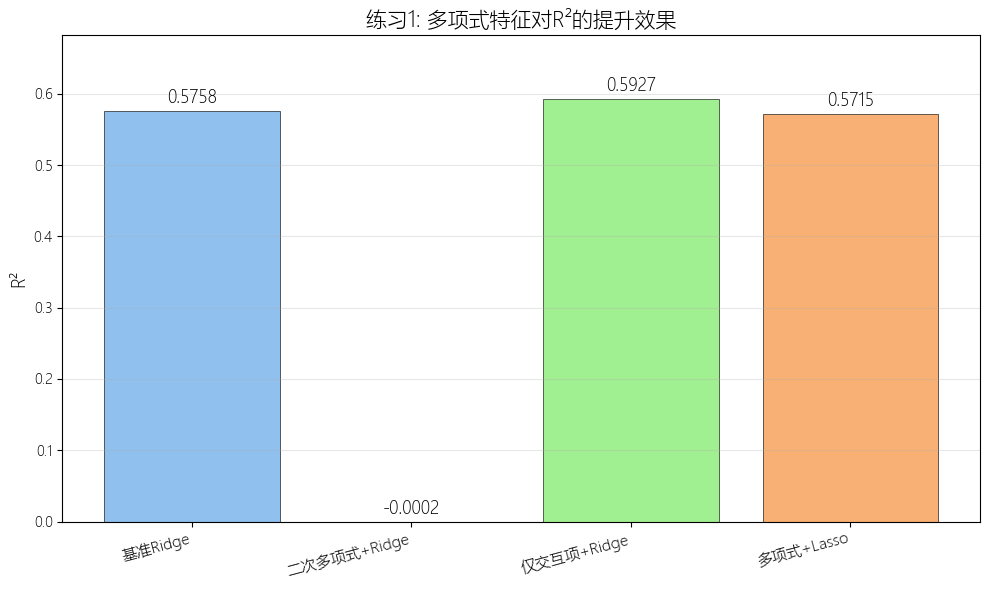

In [75]:
print("📝 练习1: 多项式特征工程")

# 解释：原文只用原始8个特征，现在通过 PolynomialFeatures 生成交互项和平方项，
# 让模型能捕捉非线性关系（如"面积*房间数"这种组合效应）

# 基准模型是之前选出的Ridge

base_r2 = results[results['模型'] == 'Ridge']['R²'].item()
base_rmse = results[results['模型'] == 'Ridge']['RMSE'].item()

# --- 1a. 只加平方项（degree=2, interaction_only=False） ---
print("\n▶ 方案A: 二次多项式（含交互项）")
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

# 标准化多项式特征
scaler_poly2 = StandardScaler()
X_train_poly2_scaled = scaler_poly2.fit_transform(X_train_poly2)
X_test_poly2_scaled = scaler_poly2.transform(X_test_poly2)

print(f"  原始特征数: {X_train.shape[1]}")
print(f"  多项式特征数: {X_train_poly2.shape[1]}")

# 用 Ridge 建模（正则化防止过拟合）
ridge_poly2 = Lasso(alpha=1.0)
ridge_poly2.fit(X_train_poly2_scaled, y_train)
y_pred_poly2 = ridge_poly2.predict(X_test_poly2_scaled)
r2_poly2 = r2_score(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mean_squared_error(y_test, y_pred_poly2))

base_rr2 = r2_score(y_test, y_pred_ridge)

print(f"  R² = {r2_poly2:.4f}, RMSE = {rmse_poly2:.4f}")
print(f"  相比基准提升: R² +{(r2_poly2 - base_rr2):.4f}")

# --- 1b. 只加交互项（interaction_only=True）---
print("\n▶ 方案B: 仅交互项（interaction_only）")
poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly_int = poly_inter.fit_transform(X_train)
X_test_poly_int = poly_inter.transform(X_test)

scaler_poly_int = StandardScaler()
X_train_poly_int_scaled = scaler_poly_int.fit_transform(X_train_poly_int)
X_test_poly_int_scaled = scaler_poly_int.transform(X_test_poly_int)

ridge_poly_int = Ridge(alpha=1.0)
ridge_poly_int.fit(X_train_poly_int_scaled, y_train)
y_pred_poly_int = ridge_poly_int.predict(X_test_poly_int_scaled)
r2_poly_int = r2_score(y_test, y_pred_poly_int)
rmse_poly_int = np.sqrt(mean_squared_error(y_test, y_pred_poly_int))

print(f"  R² = {r2_poly_int:.4f}, RMSE = {rmse_poly_int:.4f}")
print(f"  相比基准提升: R² +{(r2_poly_int - base_r2):.4f}")

# --- 1c. 用 Lasso 做自动特征选择 ---
print("\n▶ 方案C: 多项式 + Lasso（自动筛选重要特征）")
lasso_poly = Lasso(alpha=0.01, max_iter=5000)
lasso_poly.fit(X_train_poly2_scaled, y_train)
y_pred_lasso_poly = lasso_poly.predict(X_test_poly2_scaled)
r2_lasso_poly = r2_score(y_test, y_pred_lasso_poly)
rmse_lasso_poly = np.sqrt(mean_squared_error(y_test, y_pred_lasso_poly))

n_nonzero = np.sum(lasso_poly.coef_ != 0)
print(f"  非零特征数: {n_nonzero}/{len(lasso_poly.coef_)}")
print(f"  R² = {r2_lasso_poly:.4f}, RMSE = {rmse_lasso_poly:.4f}")
print(f"  相比基准提升: R² +{(r2_lasso_poly - base_r2):.4f}")

results_poly = pd.DataFrame({
    '方案': ['基准Ridge', '二次多项式+Ridge', '仅交互项+Ridge', '多项式+Lasso'],
    '特征数': [X_train.shape[1], X_train_poly2.shape[1],
             X_train_poly_int.shape[1], X_train_poly2.shape[1]],
    'R²': [base_r2, r2_poly2, r2_poly_int, r2_lasso_poly],
    'RMSE': [base_rmse, rmse_poly2, rmse_poly_int, rmse_lasso_poly],
    'R²提升': [0, r2_poly2 - base_r2, r2_poly_int - base_r2, r2_lasso_poly - base_r2]
})
print(results_poly.to_string(index=False))

# 可视化
fig1, ax1 = plt.subplots(figsize=(10, 6))
x_labels = results_poly['方案'].tolist()
r2_vals = results_poly['R²'].tolist()
colors1 = ['#7cb5ec', '#434348', '#90ed7d', '#f7a35c']
bars = ax1.bar(x_labels, r2_vals, color=colors1, alpha=0.85, edgecolor='black', linewidth=0.5)

# 在柱上标数值
for bar, val in zip(bars, r2_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_ylabel('R²', fontsize=13)
ax1.set_title('练习1: 多项式特征对R²的提升效果', fontsize=15, fontweight='bold')
ax1.set_ylim(0, max(r2_vals) * 1.15)
ax1.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

练习2: 分类阈值调优

▶ 默认阈值 0.5:
  准确率: 0.8261
              precision    recall  f1-score   support

         低价房       0.83      0.83      0.83      2077
         高价房       0.83      0.82      0.82      2051

    accuracy                           0.83      4128
   macro avg       0.83      0.83      0.83      4128
weighted avg       0.83      0.83      0.83      4128


▶ 阈值对比:
  低阈值(0.3): 准确率=0.7965, 精确率=0.7355, 召回率=0.9220, F1=0.8183
  默认(0.5): 准确率=0.8261, 精确率=0.8253, 召回率=0.8245, F1=0.8249
  高阈值(0.7): 准确率=0.7965, 精确率=0.9007, 召回率=0.6636, F1=0.7642


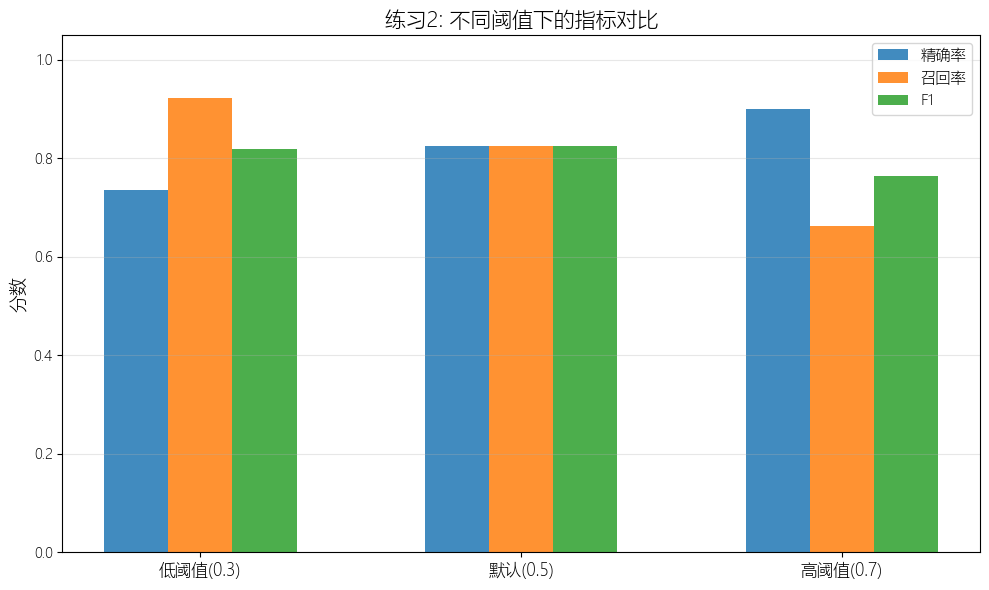

In [79]:
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve, auc)
# 练习2: 阈值调优 — 优化精确率/召回率
print( "练习2: 分类阈值调优")

# 解释：逻辑回归默认阈值=0.5，但不同业务场景需要不同的权衡——
# 如果"宁可多筛也不能漏掉高价房"→ 降低阈值提高召回率
# 如果"只推最可能的高价房给客户"→ 提高阈值提高精确率

# 构建分类数据（与原文一致）
median_price = np.median(y)
y_binary = (y > median_price).astype(int)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_binary, test_size=0.2, random_state=42)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# 训练逻辑回归
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c_scaled, y_train_c)
y_prob = log_reg.predict_proba(X_test_c_scaled)[:, 1]

# 基准：默认阈值 0.5
y_pred_default = (y_prob >= 0.5).astype(int)
print(f"\n▶ 默认阈值 0.5:")
print(f"  准确率: {accuracy_score(y_test_c, y_pred_default):.4f}")
print(classification_report(y_test_c, y_pred_default, target_names=['低价房', '高价房']))

# --- 2a. 绘制精确率-召回率曲线，找不同阈值下的效果 ---
precisions, recalls, thresholds = precision_recall_curve(y_test_c, y_prob)

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='精确率 (Precision)')
ax2.plot(thresholds, recalls[:-1], 'r-', linewidth=2, label='召回率 (Recall)')
ax2.plot(thresholds, 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10),
         'g--', linewidth=2, label='F1 Score')

# 标注三个关键阈值点
for thresh, color, label in [(0.3, '#d62728', '低阈值 0.3'),
                               (0.5, '#2ca02c', '默认 0.5'),
                               (0.7, '#1f77b4', '高阈值 0.7')]:
    idx = np.argmin(np.abs(thresholds - thresh))
    ax2.axvline(x=thresh, color=color, linestyle=':', alpha=0.7)
    ax2.annotate(f'{label}\nP={precisions[idx]:.3f}, R={recalls[idx]:.3f}',
                xy=(thresh, 0.95), fontsize=9, color=color,
                ha='center', fontweight='bold')

ax2.set_xlabel('分类阈值', fontsize=13)
ax2.set_ylabel('分数', fontsize=13)
ax2.set_title('练习2: 不同阈值下的精确率-召回率变化', fontsize=15, fontweight='bold')
ax2.legend(loc='center left', fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('第46篇_练习2_阈值调优精确率召回率曲线.png', dpi=150, bbox_inches='tight')
plt.close()

# --- 2b. 三个典型阈值的对比 ---
print("\n▶ 阈值对比:")
results_thresh = []
for thresh, label in [(0.3, '低阈值(0.3)'), (0.5, '默认(0.5)'), (0.7, '高阈值(0.7)')]:
    y_pred_t = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_c, y_pred_t).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    acc = accuracy_score(y_test_c, y_pred_t)
    results_thresh.append({
        '阈值': label, '准确率': acc, '精确率': precision,
        '召回率': recall, 'F1': f1
    })
    print(f"  {label}: 准确率={acc:.4f}, 精确率={precision:.4f}, "
          f"召回率={recall:.4f}, F1={f1:.4f}")

# --- 练习2 汇总柱状图 ---
df_thresh = pd.DataFrame(results_thresh)
fig2b, ax2b = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_thresh))
width = 0.2
metrics = ['精确率', '召回率', 'F1']
colors2b = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (metric, color) in enumerate(zip(metrics, colors2b)):
    ax2b.bar(x + i * width, df_thresh[metric], width, label=metric, color=color, alpha=0.85)

ax2b.set_ylabel('分数', fontsize=13)
ax2b.set_title('练习2: 不同阈值下的指标对比', fontsize=15, fontweight='bold')
ax2b.set_xticks(x + width)
ax2b.set_xticklabels(df_thresh['阈值'], fontsize=12)
ax2b.legend(fontsize=11)
ax2b.set_ylim(0, 1.05)
ax2b.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

 练习3: 残差分析


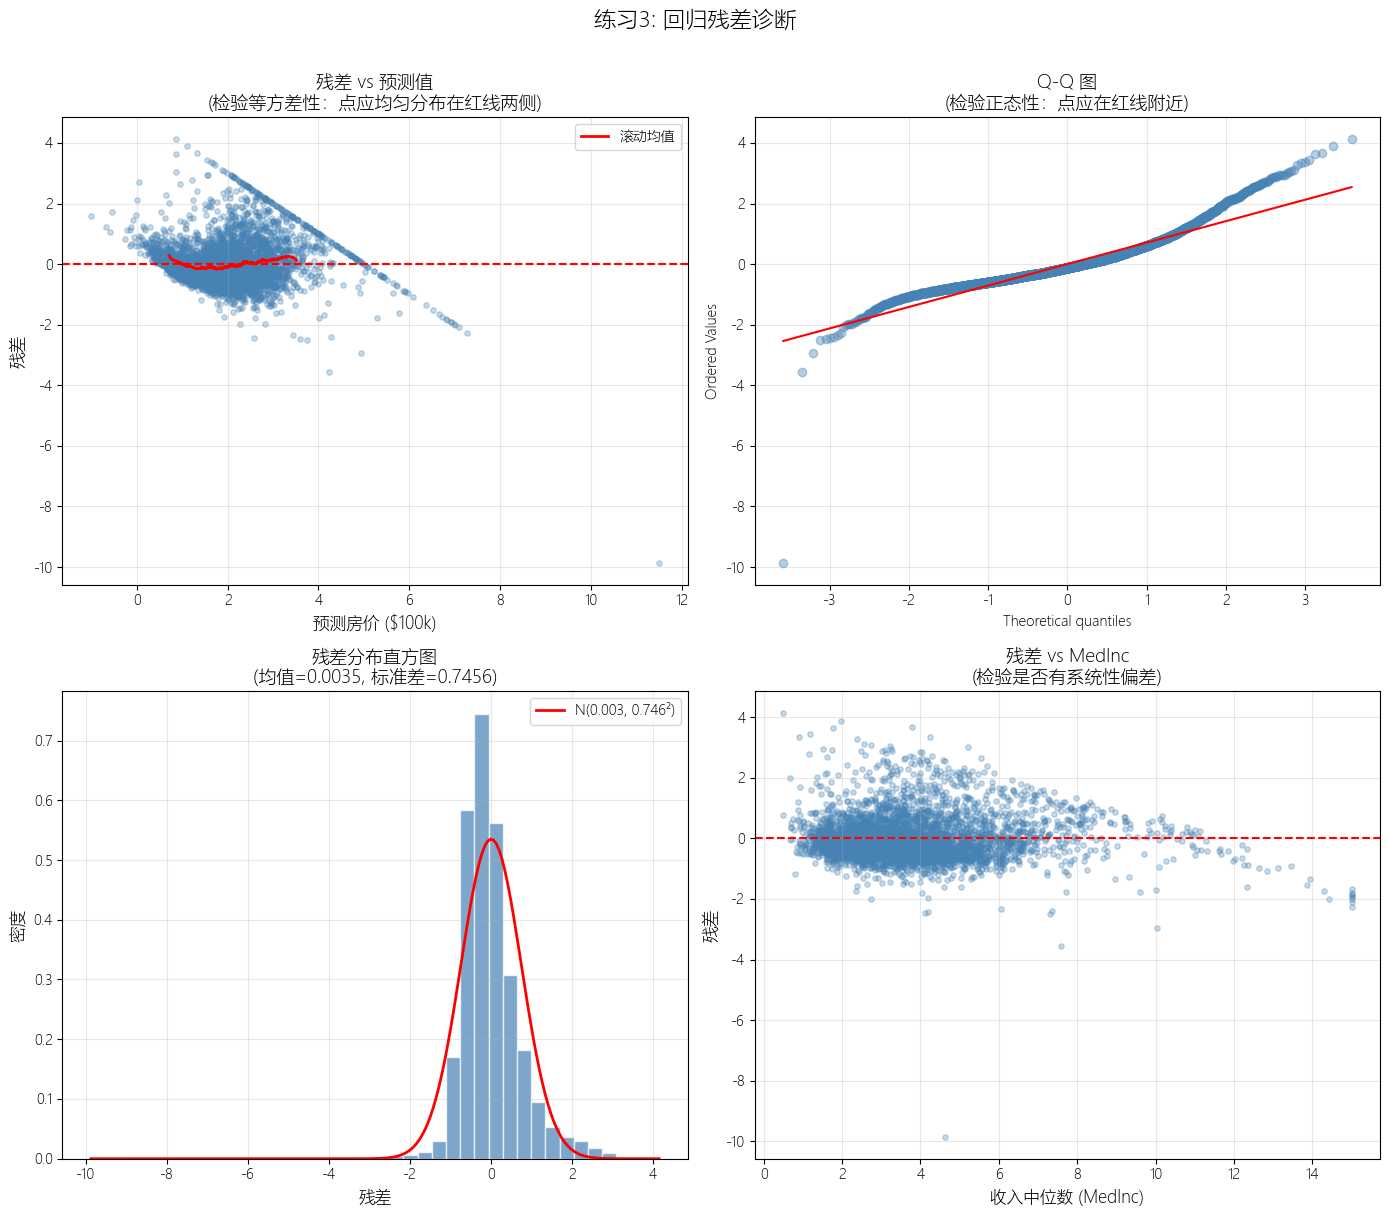


▶ 残差统计摘要:
  均值: 0.003479
  标准差: 0.745573
  Shapiro-Wilk 正态性检验: W=0.9022, p=0.0000
  偏度: 0.5457
  峰度: 10.0699

▶ 残差分析结论:
  1. 残差均值 ≈ 0.0035 → ✅ 近似为0，模型无偏
  2. 残差标准差 = 0.7456 → 预测误差约 ±1.461 ($100k)
  3. 偏度 = 0.546 → ⚠️ 有偏
  4. 峰度 = 10.070 → ⚠️ 厚尾（有异常值）


In [85]:
print(" 练习3: 残差分析")

# 解释：线性回归假设残差应满足三个条件：
#   1. 均值为0（无偏性）
#   2. 正态分布（便于做假设检验和置信区间）
#   3. 等方差性/无异方差（预测值不同时残差散布应均匀）

# 用基准 Ridge 模型的残差
# 基准Ridge: 第4.3节里的 y_pred_ridge
residuals = y_test - y_pred_ridge

fig3, axes3 = plt.subplots(2, 2, figsize=(14, 12))

# --- 3a. 残差 vs 预测值散点图（检验等方差性）---
ax = axes3[0, 0]
ax.scatter(y_pred_ridge, residuals, alpha=0.3, s=15, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('预测房价 ($100k)', fontsize=12)
ax.set_ylabel('残差', fontsize=12)
ax.set_title('残差 vs 预测值\n(检验等方差性：点应均匀分布在红线两侧)', fontsize=13)
ax.grid(alpha=0.3)

# 添加 LOWESS 平滑线（用简单滚动均值代替）
sorted_idx = np.argsort(y_pred_ridge)
window = len(y_pred_ridge) // 10
rolling_mean = pd.Series(residuals[sorted_idx]).rolling(window=window, center=True).mean()
ax.plot(y_pred_ridge[sorted_idx], rolling_mean, 'r-', linewidth=2, label='滚动均值')
ax.legend(fontsize=10)

# --- 3b. 残差直方图 + Q-Q 图 ---
# Q-Q 图
from scipy import stats as scipy_stats
ax = axes3[0, 1]
scipy_stats.probplot(residuals, dist="norm", plot=ax)
ax.get_lines()[0].set_markerfacecolor('steelblue')
ax.get_lines()[0].set_markeredgecolor('steelblue')
ax.get_lines()[0].set_alpha(0.4)
ax.get_lines()[1].set_color('red')
ax.set_title('Q-Q 图\n(检验正态性：点应在红线附近)', fontsize=13)
ax.grid(alpha=0.3)

# --- 3c. 残差直方图 ---
ax = axes3[1, 0]
ax.hist(residuals, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white')
# 叠加正态曲线
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
mu, sigma = residuals.mean(), residuals.std()
ax.plot(x_norm, scipy_stats.norm.pdf(x_norm, mu, sigma), 'r-', linewidth=2, label=f'N({mu:.3f}, {sigma:.3f}²)')
ax.set_xlabel('残差', fontsize=12)
ax.set_ylabel('密度', fontsize=12)
ax.set_title(f'残差分布直方图\n(均值={mu:.4f}, 标准差={sigma:.4f})', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- 3d. 残差 vs 关键特征（MedInc，最重要的特征）---
ax = axes3[1, 1]
medinc_test = X_test['MedInc'].values
ax.scatter(medinc_test, residuals, alpha=0.3, s=15, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('收入中位数 (MedInc)', fontsize=12)
ax.set_ylabel('残差', fontsize=12)
ax.set_title('残差 vs MedInc\n(检验是否有系统性偏差)', fontsize=13)
ax.grid(alpha=0.3)

plt.suptitle('练习3: 回归残差诊断', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 正态性统计检验
shapiro_stat, shapiro_p = scipy_stats.shapiro(residuals[:5000])  # Shapiro-Wilk 限5000样本
print(f"\n▶ 残差统计摘要:")
print(f"  均值: {residuals.mean():.6f}")
print(f"  标准差: {residuals.std():.6f}")
print(f"  Shapiro-Wilk 正态性检验: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print(f"  偏度: {scipy_stats.skew(residuals):.4f}")
print(f"  峰度: {scipy_stats.kurtosis(residuals):.4f}")

# 残差分析结论
print("\n▶ 残差分析结论:")
print(f"  1. 残差均值 ≈ {residuals.mean():.4f} → {'✅ 近似为0，模型无偏' if abs(residuals.mean()) < 0.01 else '⚠️ 偏离0'}")
print(f"  2. 残差标准差 = {residuals.std():.4f} → 预测误差约 ±{1.96*residuals.std():.3f} ($100k)")
print(f"  3. 偏度 = {scipy_stats.skew(residuals):.3f} → {'✅ 近似对称' if abs(scipy_stats.skew(residuals)) < 0.5 else '⚠️ 有偏'}")
print(f"  4. 峰度 = {scipy_stats.kurtosis(residuals):.3f} → {'✅ 接近正态' if abs(scipy_stats.kurtosis(residuals)) < 1 else '⚠️ 厚尾（有异常值）'}")

练习4: 地理可视化


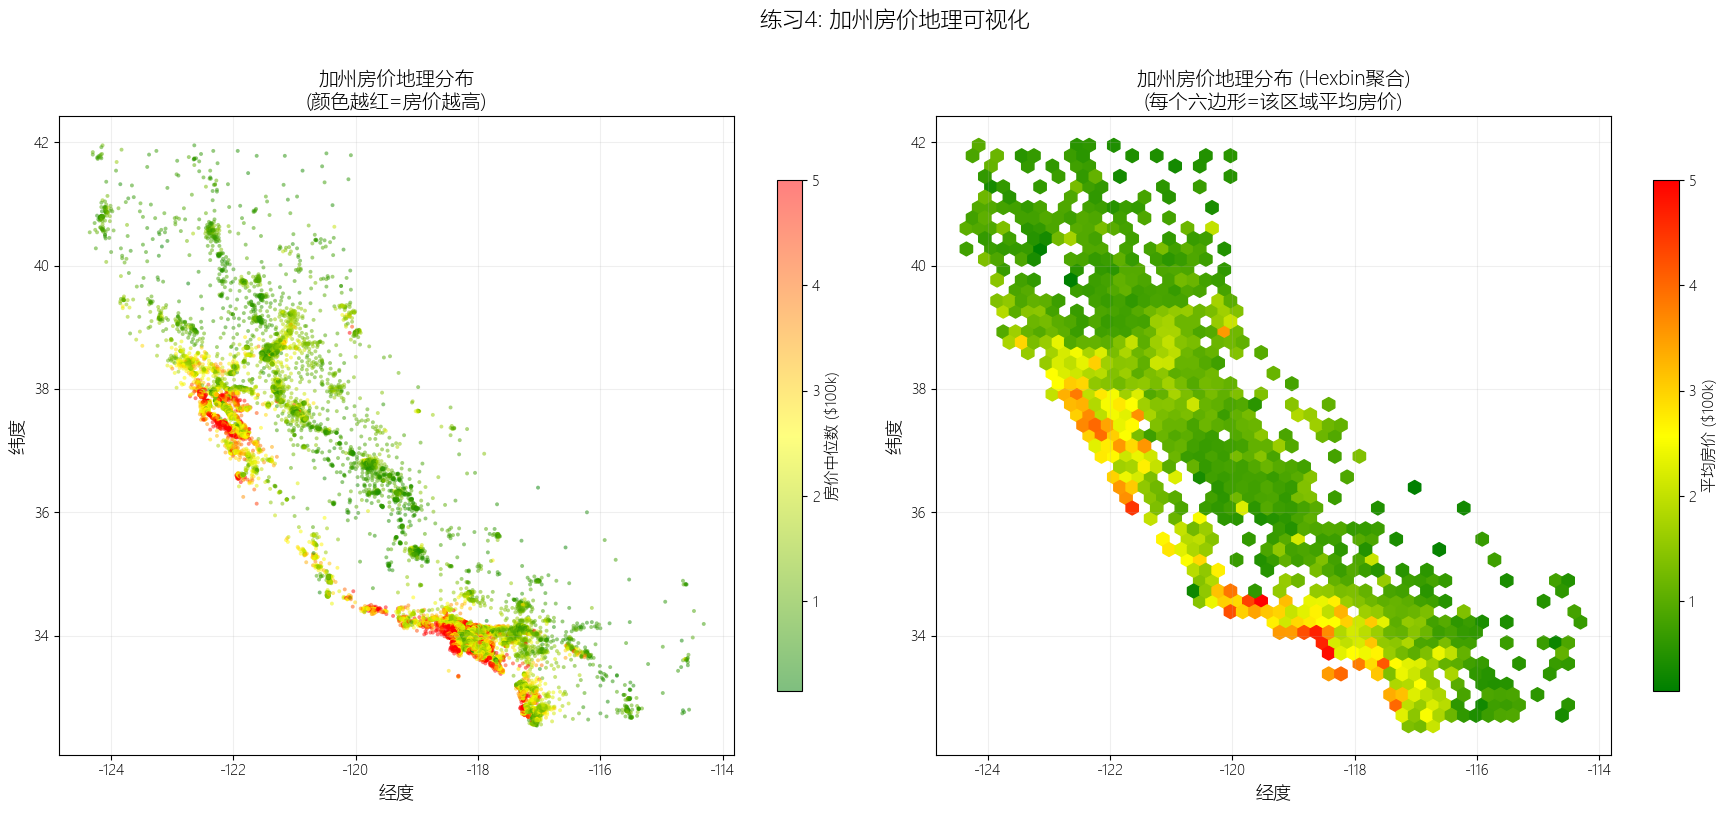


▶ 区域房价统计（均值，单位$100k）：
            mean  count    std
经度区域 纬度区域                     
西部   南部    1.779   1776  1.169
     北部    2.034   7318  1.179
东部   南部    2.137  11520  1.128
     北部    1.426     26  0.484


In [91]:
print("练习4: 地理可视化")

# 解释：加州房价数据包含经纬度信息（Longitude, Latitude），
# 可以在散点图上用颜色映射房价，直观看出哪些区域的房价更高。

lon = X['Longitude'].values
lat = X['Latitude'].values

fig4, axes4 = plt.subplots(1, 2, figsize=(18, 8))

# --- 4a. 房价地理分布散点图 ---
ax = axes4[0]
# 自定义一个colormap
my_cmap = mcolors.LinearSegmentedColormap.from_list('GnYlRd', ['green', 'yellow', 'red'])
sc = ax.scatter(lon, lat, c=y, cmap=my_cmap, alpha=0.5, s=8, edgecolors='none')
ax.set_xlabel('经度', fontsize=13)
ax.set_ylabel('纬度', fontsize=13)
ax.set_title('加州房价地理分布\n(颜色越红=房价越高)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('房价中位数 ($100k)', fontsize=11)
ax.grid(alpha=0.2)

# --- 4b. 用 hexbin 做密度聚合（更适合大规模数据）---
ax = axes4[1]
# hexbin = hexagon + bin,把地图分成一个个小六边形，统计每个格子里的房价
# cmap='GnYlRd',颜色方案： Gn = Green（绿） Rd = Red（红） Yl = Yellow（黄）; 房价低 = 绿色，中等 = 黄色，高 = 红色
# educe_C_function=np.mean, 一个格子里有很多房子,计算这个格子的平均房价,用平均值来决定颜色
import matplotlib.colors as mcolors


hb = ax.hexbin(lon, lat, C=y, gridsize=50, cmap=my_cmap, reduce_C_function=np.mean)
ax.set_xlabel('经度', fontsize=13)
ax.set_ylabel('纬度', fontsize=13)
ax.set_title('加州房价地理分布 (Hexbin聚合)\n(每个六边形=该区域平均房价)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(hb, ax=ax, shrink=0.8)
cbar.set_label('平均房价 ($100k)', fontsize=11)
ax.grid(alpha=0.2)

plt.suptitle('练习4: 加州房价地理可视化', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- 4c. 按区域统计分析 ---
# 将加州大致分为四个区域
lon_bins = pd.cut(lon, bins=2, labels=['西部', '东部'])
lat_bins = pd.cut(lat, bins=2, labels=['南部', '北部'])

region_stats = pd.DataFrame({
    '经度区域': lon_bins,
    '纬度区域': lat_bins,
    '房价': y
})

print("\n▶ 区域房价统计（均值，单位$100k）：")
region_pivot = region_stats.groupby(['经度区域', '纬度区域'])['房价'].agg(['mean', 'count', 'std']).round(3)
print(region_pivot.to_string())

可以看到高价住宅大多坐落于加州沿海的发达城市地带。

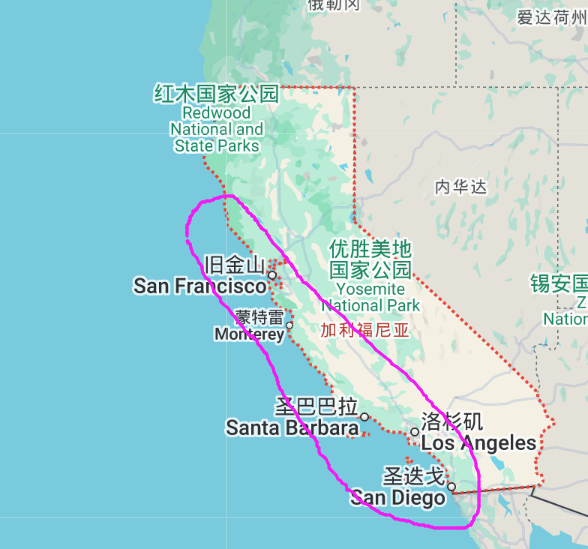

---

## 下期预告

> **第 47 篇：机器学习概述与 Scikit-learn 工作流程**
>
> 第四阶段收官！下一篇开始第五阶段：机器学习。先从 Scikit-learn 的完整工作流程开始，认识 ML 的全貌。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*